In [8]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import time

print("Alle Pakete geladen ✓")

Alle Pakete geladen ✓


In [9]:
np.random.seed(42)
n = 1000

druck = np.random.normal(150, 20, n)
temperatur = np.random.normal(75, 10, n)
durchfluss = np.random.normal(50, 8, n)
vibration = np.random.normal(0.5, 0.1, n)
betriebsstunden = np.random.uniform(0, 10000, n)

ausfall = (
    0.3 * (temperatur / 100) +
    0.4 * (vibration / 1.0) +
    0.2 * (betriebsstunden / 10000) +
    0.1 * (druck / 200) +
    np.random.normal(0, 0.05, n)
).clip(0, 1)

df = pd.DataFrame({
    'Druck': druck,
    'Temperatur': temperatur,
    'Durchfluss': durchfluss,
    'Vibration': vibration,
    'Betriebsstunden': betriebsstunden,
    'Ausfall': ausfall
})

X = df.drop('Ausfall', axis=1)
y = df['Ausfall']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Daten geladen: {df.shape}")

Daten geladen: (1000, 6)


In [10]:
# LightGBM trainieren
start = time.time()

model_lgb = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
model_lgb.fit(X_train, y_train)

zeit_lgb = time.time() - start

# Ergebnisse
y_pred_lgb = model_lgb.predict(X_test)
rmse_lgb = mean_squared_error(y_test, y_pred_lgb) ** 0.5
r2_lgb = r2_score(y_test, y_pred_lgb)

print(f"LightGBM — RMSE: {rmse_lgb:.4f} | R²: {r2_lgb:.4f} | Zeit: {zeit_lgb:.2f}s")

LightGBM — RMSE: 0.0534 | R²: 0.6504 | Zeit: 0.10s


In [11]:
# XGBoost trainieren — zum Vergleich
start = time.time()

model_xgb = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
model_xgb.fit(X_train, y_train)

zeit_xgb = time.time() - start

# Ergebnisse
y_pred_xgb = model_xgb.predict(X_test)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb) ** 0.5
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost  — RMSE: {rmse_xgb:.4f} | R²: {r2_xgb:.4f} | Zeit: {zeit_xgb:.2f}s")
print(f"LightGBM — RMSE: {rmse_lgb:.4f} | R²: {r2_lgb:.4f} | Zeit: {zeit_lgb:.2f}s")

XGBoost  — RMSE: 0.0581 | R²: 0.5874 | Zeit: 0.17s
LightGBM — RMSE: 0.0534 | R²: 0.6504 | Zeit: 0.10s


In [12]:
# Benchmark Tabelle
ergebnisse = pd.DataFrame({
    'Modell': ['XGBoost v1', 'LightGBM'],
    'RMSE': [rmse_xgb, rmse_lgb],
    'R²': [r2_xgb, r2_lgb],
    'Zeit (s)': [zeit_xgb, zeit_lgb]
})

print(ergebnisse.to_string(index=False))

    Modell     RMSE       R²  Zeit (s)
XGBoost v1 0.058064 0.587366  0.171586
  LightGBM 0.053448 0.650373  0.097111


In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'random_state': 42,
        'verbose': -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return mean_squared_error(y_test, y_pred) ** 0.5

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f"Beste Parameter: {study.best_params}")
print(f"Bestes RMSE: {study.best_value:.4f}")
print(f"LightGBM vorher: 0.0534")

Beste Parameter: {'n_estimators': 84, 'learning_rate': 0.11663124742119012, 'num_leaves': 99, 'min_child_samples': 39}
Bestes RMSE: 0.0510
LightGBM vorher: 0.0534


In [14]:
# Optimiertes Modell trainieren
model_lgb_opt = lgb.LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
model_lgb_opt.fit(X_train, y_train)

y_pred_opt = model_lgb_opt.predict(X_test)
rmse_opt = mean_squared_error(y_test, y_pred_opt) ** 0.5
r2_opt = r2_score(y_test, y_pred_opt)

print(f"LightGBM Default:   RMSE {0.0534:.4f} | R² {0.6504:.4f}")
print(f"LightGBM + Optuna:  RMSE {rmse_opt:.4f} | R² {r2_opt:.4f}")

joblib.dump(model_lgb_opt, 'model_lgb_v1.pkl')
print("\nModell gespeichert ✓")

LightGBM Default:   RMSE 0.0534 | R² 0.6504
LightGBM + Optuna:  RMSE 0.0510 | R² 0.6814

Modell gespeichert ✓


In [15]:
# Komplette Übersicht aller Modelle
ergebnisse = pd.DataFrame({
    'Modell': ['XGBoost v1', 'XGBoost v2 (Early Stopping)', 'LightGBM Default', 'LightGBM + Optuna'],
    'RMSE': [0.0581, 0.0531, 0.0534, rmse_opt],
    'R²': [0.5874, 0.6554, 0.6504, r2_opt]
})

print(ergebnisse.to_string(index=False))
print(f"\nBestes Modell: LightGBM + Optuna")
print(f"Verbesserung gegenüber Start: {((0.0581 - rmse_opt) / 0.0581 * 100):.1f}%")

                     Modell     RMSE       R²
                 XGBoost v1 0.058100 0.587400
XGBoost v2 (Early Stopping) 0.053100 0.655400
           LightGBM Default 0.053400 0.650400
          LightGBM + Optuna 0.051019 0.681427

Bestes Modell: LightGBM + Optuna
Verbesserung gegenüber Start: 12.2%


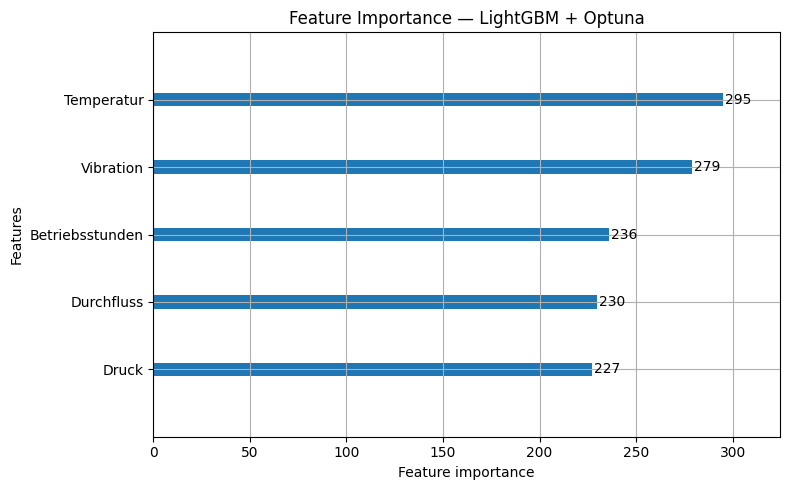

In [17]:
# Feature Importance LightGBM
lgb.plot_importance(model_lgb_opt, figsize=(8, 5))
plt.title("Feature Importance — LightGBM + Optuna")
plt.tight_layout()
plt.show()

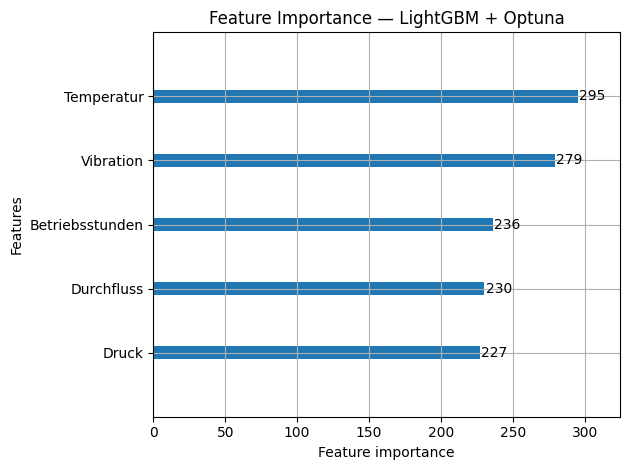

Plot gespeichert ✓


In [18]:
import os
os.makedirs('figures', exist_ok=True)

lgb.plot_importance(model_lgb_opt)
plt.title("Feature Importance — LightGBM + Optuna")
plt.tight_layout()
plt.savefig('figures/feature_importance_lgb.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot gespeichert ✓")